In [1913]:
from Dataset.DataSetLoaders import ChessDataset

import numpy as np
from matplotlib import pyplot as plt

In [2]:
ds = ChessDataset.GameDataset(
    config={
        "img_size": (640,640),
        "include_only": "valid"
    }
)

In [1934]:
i = 0
i = 2139

2139 / 2141
/mnt/D/University/Thesis_Dataset/Games/Training_Session/game_3154.jpg


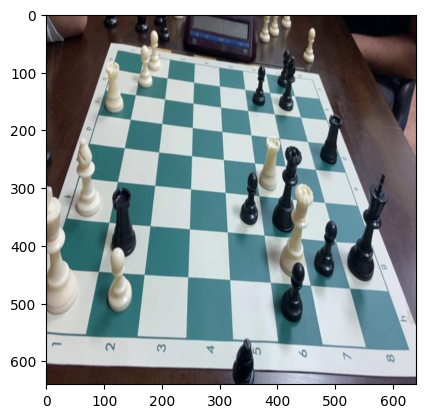

In [1935]:
img, y = ds[i]

plt.imshow(img.permute(1,2,0));
print(f"{i} / {len(ds)-1}")
print(y["image_path"])

i += 1

In [1936]:
with open("labels.txt", "r") as f:
    data = f.read()

In [1942]:
data = data.strip()

mv_idx = np.zeros(len(ds), dtype=np.int8)

for line in data.split("\n"):
    idx, rng = line.split(":")
    idx = int(idx)

    if rng == "-":
        lwr, upr = None, None
        continue

    bounds = list(map(lambda x: int(x), rng.split("-")))
    lwr = bounds[0]
    if len(bounds) == 1:
        upr = bounds[0]+1
    else:
        upr = bounds[1]+1

    mv_idx[lwr:upr] = idx

In [1943]:
with open("tmp_labels.npy", "wb") as f:
    np.save(f, mv_idx)